In [1]:
# Imports and loading of NEURON dll
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import bz2
import pickle
import _pickle as cPickle

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

## Plot monophasic results

In [24]:
# load in S-D data pickle files 
electrodes = []
# -------- test electrodes ---------
for x in range(31):
    electrodes.append([-1000, 0, 47+(x*0.5)])

thresholds = []

for elec in electrodes: 
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/ERF/monophasic/15um/0.05ms/anodic_'+\
                str(elec[0])+'_'+\
                str(elec[1])+'_'+str(elec[2])+'_erf.pkl'
    
    data = decompress_pickle(filename)

    thresholds.append(data[0])


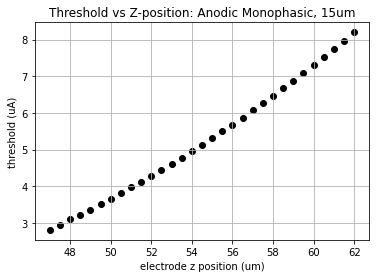

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

for i,elec in enumerate(electrodes):
    ax.scatter(elec[2], thresholds[i], c='k')

ax.set_ylabel('threshold (uA)')
ax.set_xlabel('electrode z position (um)')
ax.set_title('Threshold vs Z-position: Anodic Monophasic, 15um')
ax.grid()

## Plot triphasic results

In [5]:
# load in S-D data pickle files 
electrodes = []
# -------- test electrodes ---------
for x in range(31):
    electrodes.append([-1000, 0, 45+(x*0.5)])

thresholds = []

for elec in electrodes: 
    filename = '/Volumes/Scratch/Users/vilkhu/sim-data/ERF/triphasic/fixed/cathodic_'+\
                str(elec[0])+'_'+\
                str(elec[1])+'_'+str(elec[2])+'_erf.pkl'
    
    data = decompress_pickle(filename)

    thresholds.append(data[0])

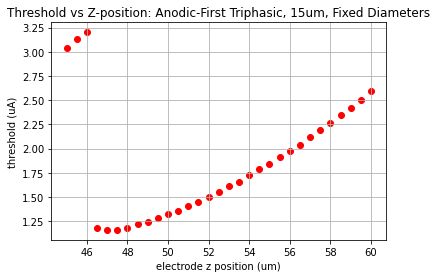

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

for i,elec in enumerate(electrodes):
    # ax.scatter(elec[2], thresholds[i]*(2/3), c='r') # scaled
    ax.scatter(elec[2], thresholds[i], c='r') # not scaled

ax.set_ylabel('threshold (uA)')
ax.set_xlabel('electrode z position (um)')
ax.set_title('Threshold vs Z-position: Anodic-First Triphasic, 15um, Fixed Diameters')
ax.grid()